# Predicting Student Health Risk — Full Pipeline

Kaggle Playground Series S6E7 (https://www.kaggle.com/competitions/playground-series-s6e7) 를 기반으로
학생 건강 위험도(`health_condition`: at-risk / unhealthy / fit)를 예측하는 전체 파이프라인을
`src/` 모듈을 그대로 불러와 재현하는 노트북입니다.

무거운 계산은 이미 `python -m src.train` 등으로 한 번 실행해 `reports/`, `models/` 에
저장해 두었습니다. 처음부터 재현하려면 이 노트북의 각 셀을 위에서 아래로 실행하면 됩니다.


In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config
from src.data import load_train, split_train_valid
from src.features import add_derived_features
from src.pipeline import prepare_features

pd.set_option("display.max_columns", 50)


## 1. 데이터 로드 & 개요

Kaggle 데이터를 `data/raw/train.csv`, `data/raw/test.csv` 로 내려받았다는 전제입니다.

In [2]:
df = load_train()
print(df.shape)
df.head()


(690088, 15)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
df.isna().mean().sort_values(ascending=False).head(10) * 100


stress_level               12.000064
sleep_duration             11.012943
sleep_quality               8.452690
calorie_expenditure         7.658878
water_intake                6.300211
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
step_count                  2.016554
bmi                         2.013946
dtype: float64

## 2. 타깃 분포 — 압도적인 불균형

`at-risk` 가 85.9%를 차지하는 불균형 데이터입니다. "단순 정확도"만으로는 소수 클래스
(fit, unhealthy)를 놓쳐도 점수가 높게 나올 수 있어 **Balanced Accuracy**(클래스별
recall의 평균)를 평가지표로 채택했습니다.

In [4]:
df[config.TARGET_COL].value_counts(normalize=True).mul(100).round(2)


health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64

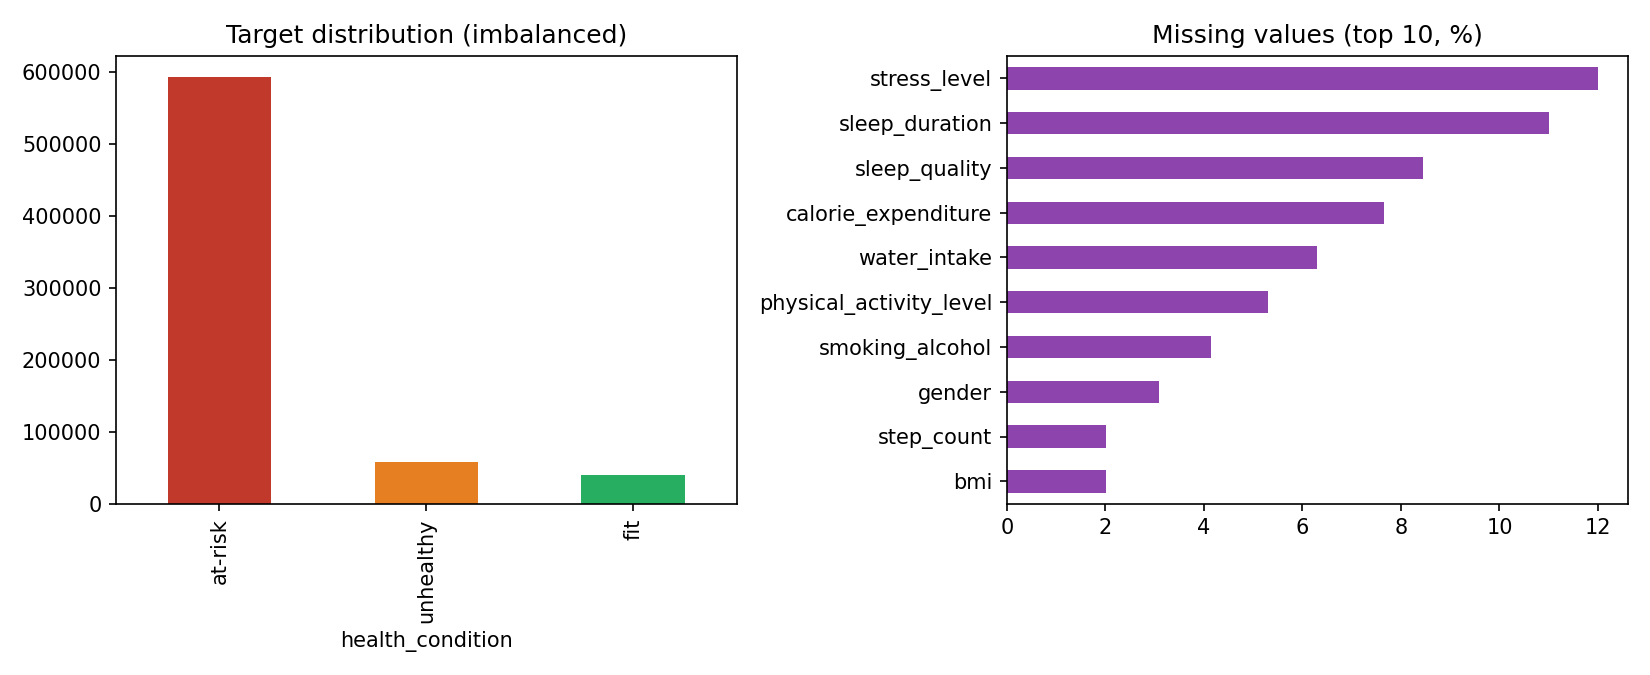

In [5]:
display(Image(filename=str(config.FIGURES_DIR / "target_and_missing.png")))


## 3. 파생변수 생성 (3축 설계)

회복/활동/섭식 3축 원본 변수를 바탕으로 도메인 지식을 반영한 파생변수를 만듭니다
(`src/features.py`).

| 파생변수 | 계산식 | 의미 |
|---|---|---|
| `fatigue_index` | stress - sleep (+screen_time 있으면 가산) | 피로 누적 정도 |
| `activity_index` | exercise + steps/1000 | 신체 활동 수준 |
| `health_habit_score` | sleep + hydration + exercise | 건강 생활 습관 점수 |
| `bmi_step_ratio` | BMI / steps | 체중 대비 활동량 |
| `sleep_x_quality` | sleep × sleep_quality | 수면의 양과 질 반영 |
| `hr_per_bmi`, `cal_per_step`, `cal_per_min` | — | 보조 파생변수 (Top-20 피처 중요도에 등장) |


In [6]:
enriched = add_derived_features(df)
enriched[config.DERIVED_FEATURE_NAMES + [config.TARGET_COL]].head()


,fatigue_index,activity_index,health_habit_score,bmi_step_ratio,sleep_x_quality,hr_per_bmi,cal_per_step,cal_per_min,health_condition
0,-3.22,21.126,26.88,0.019337,5.22,2.751364,1.638282,104.519231,unhealthy
1,-5.53,59.791,56.69,0.002612,5.53,2.759288,0.198746,38.624754,at-risk
2,-3.29,52.316,44.99,0.001726,0.00,3.072535,0.189069,68.746803,unhealthy
3,-2.70,67.074,66.62,0.003224,4.70,3.337657,0.366551,43.185550,unhealthy
4,NaN,52.584,55.48,0.004319,7.23,2.580872,0.388762,54.468085,at-risk


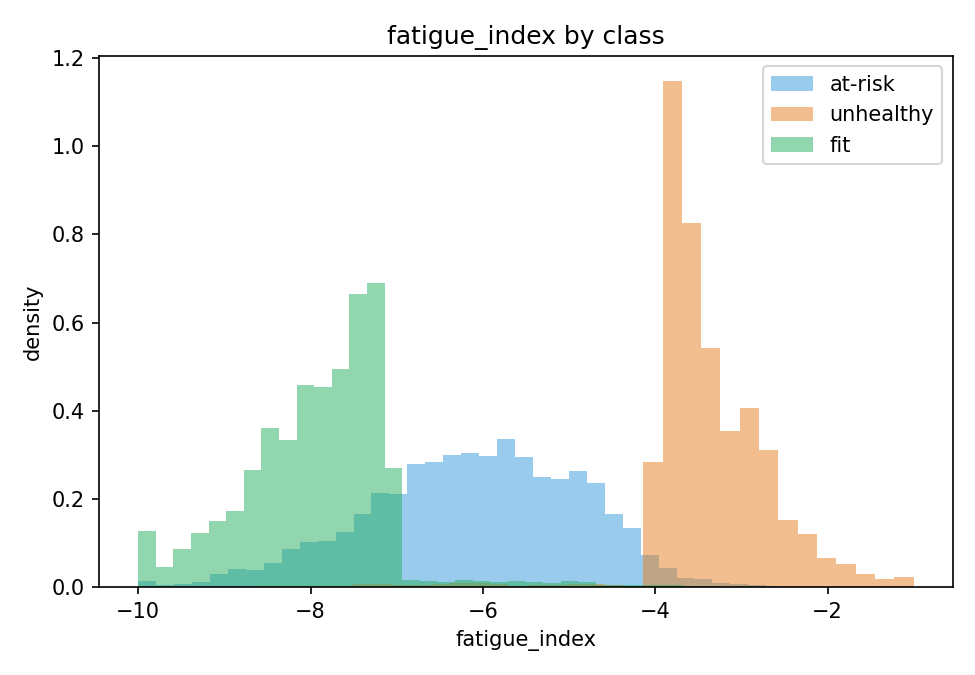

In [7]:
display(Image(filename=str(config.FIGURES_DIR / "fatigue_index_by_class.png")))


## 4. 통계검정 — 파생변수가 클래스를 실제로 구분하는가 (ANOVA)

`scipy.stats.f_oneway` + eta-squared 로 클래스 간 차이의 통계적 유의성과 효과크기를
확인합니다. `fatigue_index` 하나의 효과크기가 압도적으로 큽니다.

In [8]:
anova = pd.read_csv(config.METRICS_DIR / "anova_effect_sizes.csv")
anova


,feature,f_stat,p_value,eta_squared
0,fatigue_index,150916.310478,0.0,0.358420
1,sleep_x_quality,14554.352193,0.0,0.049231
2,activity_index,15687.040668,0.0,0.044771
3,health_habit_score,12543.332429,0.0,0.042176
4,bmi_step_ratio,5664.704666,0.0,0.016813
5,cal_per_step,4353.438040,0.0,0.013753
6,hr_per_bmi,4620.955308,0.0,0.013636
7,cal_per_min,841.695886,0.0,0.002661


## 5. 전처리 파이프라인

`ColumnTransformer` 로 수치형(중앙값 대체 + 표준화)과 범주형(최빈값 대체 + 원-핫 인코딩)을
분리 처리합니다 (`src/pipeline.py`).

In [9]:
train_df, valid_df = split_train_valid(df)
X_train = prepare_features(train_df)
X_valid = prepare_features(valid_df)
print(X_train.shape, X_valid.shape)
X_train.dtypes


(552070, 21) (138018, 21)


sleep_duration             float64
heart_rate                 float64
step_count                 float64
exercise_duration          float64
calorie_expenditure        float64
water_intake               float64
bmi                        float64
fatigue_index              float64
activity_index             float64
health_habit_score         float64
bmi_step_ratio             float64
sleep_x_quality            float64
hr_per_bmi                 float64
cal_per_step               float64
cal_per_min                float64
stress_level                   str
sleep_quality                  str
physical_activity_level        str
diet_type                      str
smoking_alcohol                str
gender                         str
dtype: object

## 6. 모델 비교 (7종 오디션)

`python -m src.train` 실행 결과 (`reports/metrics/model_comparison.csv`).
Logistic Regression → Random Forest → Extra Trees → HistGradientBoosting → XGBoost → LightGBM → CatBoost
7개 모델을 동일한 파이프라인/`class_weight="balanced"` 조건으로 비교했습니다.

In [10]:
leaderboard = pd.read_csv(config.METRICS_DIR / "model_comparison.csv")
leaderboard


,model,balanced_accuracy,accuracy,train_seconds
0,HistGradientBoost,0.943295,0.938704,4.730559
1,CatBoost,0.942227,0.940718,16.097436
2,LightGBM,0.940112,0.947079,9.561743
3,LogisticRegression,0.891653,0.827378,4.815041
4,XGBoost,0.874737,0.964693,11.764095
5,RandomForest,0.857311,0.965070,64.764011
6,ExtraTrees,0.851256,0.964099,48.893670


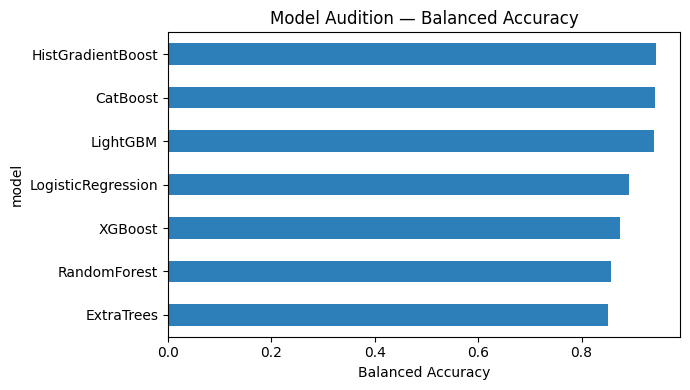

In [11]:
fig, ax = plt.subplots(figsize=(7,4))
leaderboard.sort_values("balanced_accuracy").plot.barh(x="model", y="balanced_accuracy", ax=ax, legend=False, color="#2c7fb8")
ax.set_xlabel("Balanced Accuracy")
ax.set_title("Model Audition — Balanced Accuracy")
plt.tight_layout()
plt.show()


**HistGradientBoosting** 이 CatBoost와 사실상 동률(BA 기준)이면서 학습 시간이
훨씬 짧아(약 5초 vs 16초) 최종 모델로 채택되었습니다.

## 7. 확률 보정(Calibration)과 함정

`CalibratedClassifierCV(method="sigmoid")` 로 보정하면 확률 자체는 더 신뢰할 수 있게 되지만,
**단순 argmax로 바로 분류하면 오히려 Balanced Accuracy가 하락**하는 현상을 발견했습니다.
보정이 확률을 실제 클래스 비율(85.9/8.4/5.8%)로 되돌리면서, 학습 때 `class_weight="balanced"`
로 얻은 소수 클래스 재현율 이득이 상쇄되기 때문입니다.

이를 해결하기 위해 **사전확률 보정(prior-adjustment)**: `보정된 확률 / 학습 시 클래스 비율` 로
다시 argmax를 취하는 방식을 적용했습니다 (`src/models.py::PriorAdjustedClassifier`).

In [12]:
import json
metrics = json.load(open(config.METRICS_DIR / "final_metrics.json", encoding="utf-8"))
pd.Series(metrics)


best_model                                            HistGradientBoost
balanced_accuracy_before_calibration                           0.942437
accuracy_before_calibration                                    0.936392
balanced_accuracy_after_calibration_naive_argmax               0.865384
accuracy_after_calibration_naive_argmax                        0.965939
balanced_accuracy_after_calibration_prior_adjusted              0.94154
accuracy_after_calibration_prior_adjusted                      0.929756
train_rows                                                       552070
valid_rows                                                       138018
bake_off_sample_size                                             150000
dtype: object

## 8. 최종 평가 — 혼동행렬 & 피처 중요도

`python -m src.evaluate` 실행 결과.

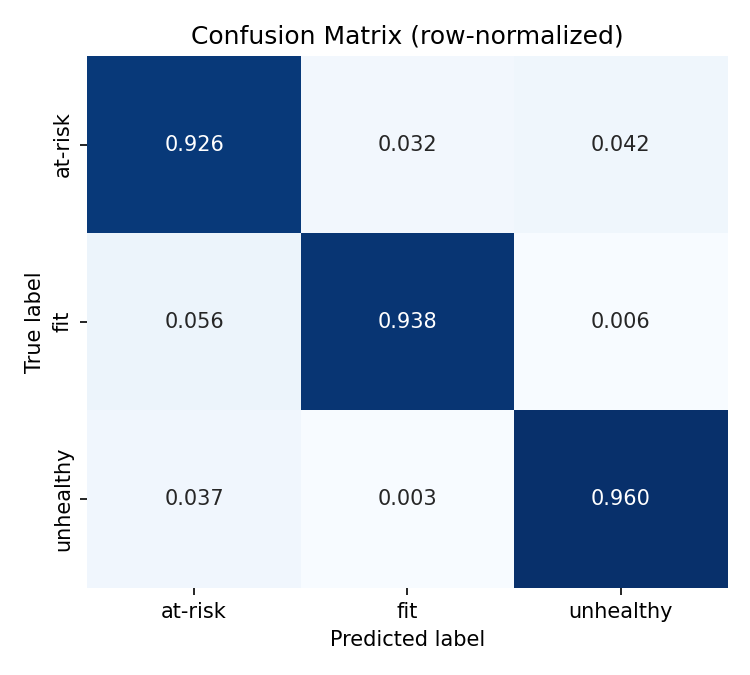

In [13]:
display(Image(filename=str(config.FIGURES_DIR / "confusion_matrix.png")))


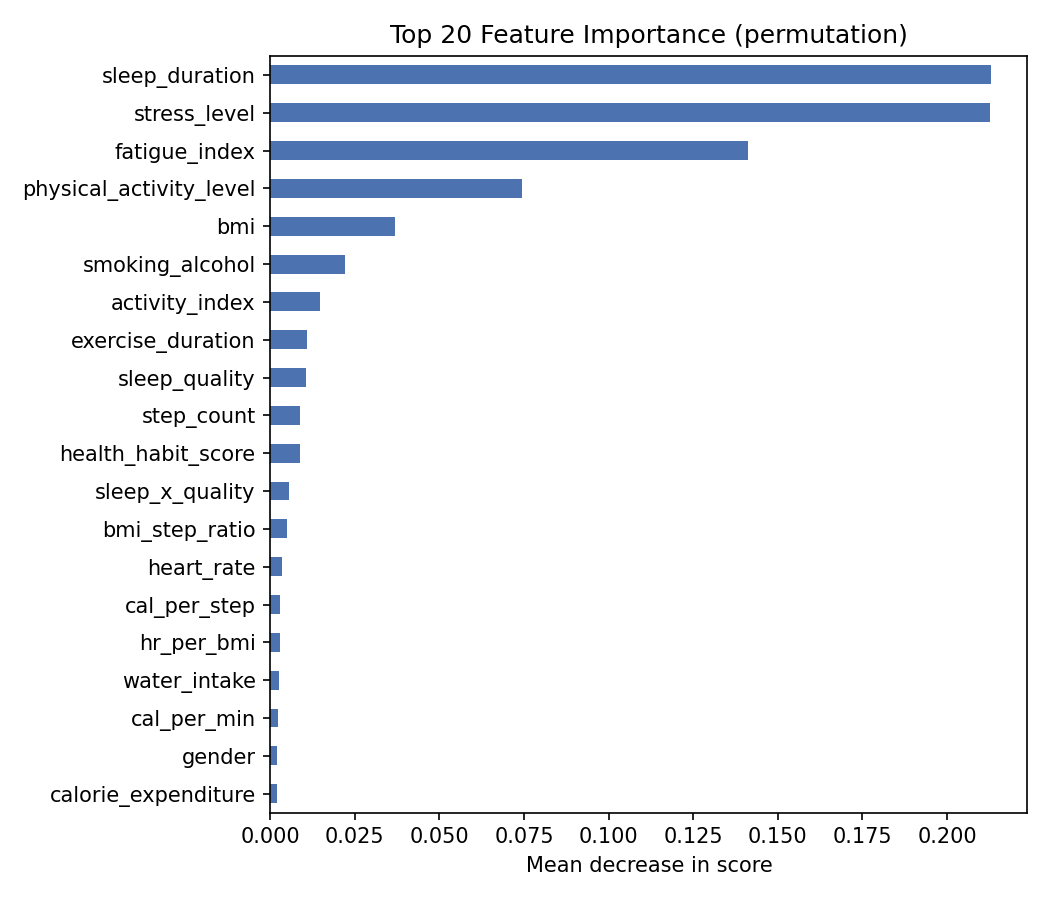

In [14]:
display(Image(filename=str(config.FIGURES_DIR / "feature_importance.png")))


## 9. 결론

- 이 노트북에서 재현한 최종 Balanced Accuracy(사전확률 보정 후, Valid 기준)는
  위 `final_metrics.json` 값을 참고하세요.
- 점수 향상의 대부분은 **클래스 불균형 처리**(`class_weight="balanced"`)에서 나왔고,
  파생변수 자체의 성능 기여는 제한적이었습니다. 다만 파생변수는 **해석 가능성**
  (어떤 교사가 무엇을 해야 하는지) 측면에서 여전히 중요합니다.
- 다음 단계: `python -m src.predict` 로 `reports/submission.csv` 를 생성해 Kaggle에 제출할 수 있습니다.
